<a href="https://colab.research.google.com/github/MM33NA/AI-machine-learning-projects/blob/main/exploratory-data-analysis/AAL_Sales_Analysis_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **AAL Apparel — Sales Analysis | Q4 2020**

**Project Statement:**

AAL, established in 2000, is a well-known brand in Australia, particularly recognized for its clothing business. It has opened branches in various states, metropolises, and tier-1 and tier-2 cities across the country.

The brand caters to all age groups, from kids to the elderly. Currently experiencing a surge in business, AAL is actively pursuing expansion opportunities. To facilitate informed investment decisions, the CEO has assigned the responsibility to the head of AAL's Sales & Marketing (S&M) department:

- Identify the states that are generating the highest revenues.
- Develop sales programs for states with lower revenues.

Analyse the sales data for Q4 in Australia on a state-by-state basis and provide insights to assist in making data-driven decisions for the upcoming year.

*Dataset: `AusApparalSales4thQrt2020.csv`*

---
#### **0. Import Libraries & Load Data**

In [57]:
# Standard data manipulation
import os
import pandas as pd
import numpy as np

# Statistical testing
from scipy.stats import shapiro

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

print("All libraries imported successfully.")

All libraries imported successfully.


In [58]:
# ── Load dataset from GitHub ──────────────────────────────────────────────────
repo_url  = "https://github.com/MM33NA/AI-machine-learning-projects.git"
repo_name = "AI-machine-learning-projects"

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print("Repository already exists. Pulling latest changes...")
    %cd {repo_name}
    !git pull
    %cd ..

os.chdir(f"{repo_name}/exploratory-data-analysis")
print("\nFiles available:")
!ls

Cloning into 'AI-machine-learning-projects'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 983.07 KiB | 4.96 MiB/s, done.
Resolving deltas: 100% (7/7), done.

Files available:
AusApparalSales4thQrt2020.csv  README.md  sales_analysis.ipynb


In [59]:
# Load dataset
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


---
### **1. Data Wrangling**

### a. Missing Values

In [60]:
# Inspect dataset structure and check for missing values
df.info()
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB

Missing values per column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


**Observation:**
- [X] **No missing values** — all 7,560 records are complete across all 6 columns.
  - If missing values were present: use `dropna()` for losses < 5%, or `fillna(median)` for larger gaps to preserve data volume.
- [ ] The `Date` column is stored as `object` (string) — this must be converted to `datetime64` to enable time-series operations.

### b. Data Types

In [61]:
# Convert Date from object to datetime and create a date-indexed copy for resampling
df['Date']   = pd.to_datetime(df['Date'])
df_indexed   = df.set_index('Date')

print("Updated data types:")
print(df.dtypes)

Updated data types:
Date     datetime64[ns]
Time             object
State            object
Group            object
Unit              int64
Sales             int64
dtype: object


**Observation:**
- [X] `Date` converted from `object` → `datetime64[ns]`.
  - This enables chronological sorting, periodic grouping (weekly / monthly / quarterly), and time-series plotting.

### c. Errors & Inconsistencies

In [62]:
# Inspect unique values in all categorical columns for whitespace or typos
for col in df.select_dtypes(include='object').columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'Time': [' Morning' ' Afternoon' ' Evening']
Unique values in 'State': [' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']
Unique values in 'Group': [' Kids' ' Men' ' Women' ' Seniors']


**Observation:**
- [ ] **Whitespace error detected** — all categorical columns (`Time`, `State`, `Group`) contain leading spaces (e.g., `' Morning'` instead of `'Morning'`).
- [ ] Fix: apply `.str.strip()` to remove the extra spaces.

In [63]:
# Strip leading/trailing whitespace from all categorical columns
for col in ['Time', 'State', 'Group']:
    df[col] = df[col].str.strip()

# Rebuild the date-indexed copy after cleaning
df_indexed = df.set_index('Date')

# Verify
print("After cleaning:")
for col in ['Time', 'State', 'Group']:
    print(f"  {col}: {df[col].unique()}")

After cleaning:
  Time: ['Morning' 'Afternoon' 'Evening']
  State: ['WA' 'NT' 'SA' 'VIC' 'QLD' 'NSW' 'TAS']
  Group: ['Kids' 'Men' 'Women' 'Seniors']


**Observation:**
- [X] Whitespace removed from `Time`, `State`, and `Group` — all values are now clean.

### d. Outliers

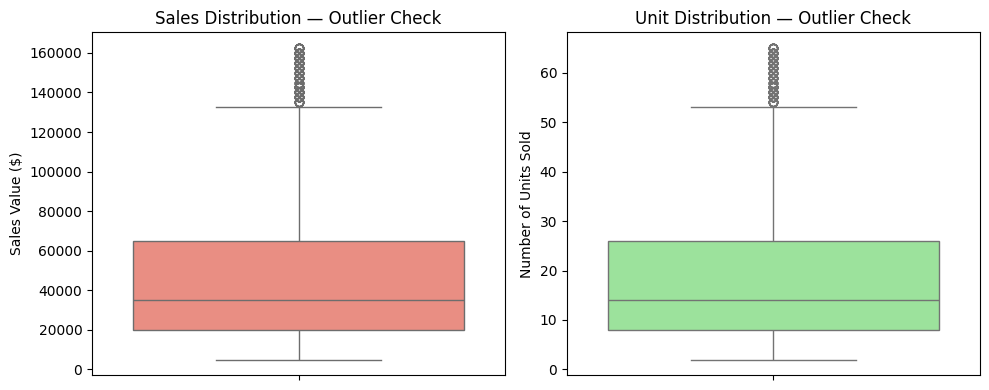

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df['Sales'], color='salmon',     ax=axes[0])
axes[0].set_title('Sales Distribution — Outlier Check')
axes[0].set_ylabel('Sales Value ($)')

sns.boxplot(y=df['Unit'],  color='lightgreen', ax=axes[1])
axes[1].set_title('Unit Distribution — Outlier Check')
axes[1].set_ylabel('Number of Units Sold')

plt.tight_layout()
plt.show()

**Observation:**
- [X] **Outliers retained** — both `Sales` `(up to $162,500)` and `Unit` (up to 65) contain high-value observations.
  - These are **not data errors** — they represent genuine high-capacity bulk transactions and carry valid business signal.
  - Removing them would understate peak demand. We keep them.

### e. Normality Test

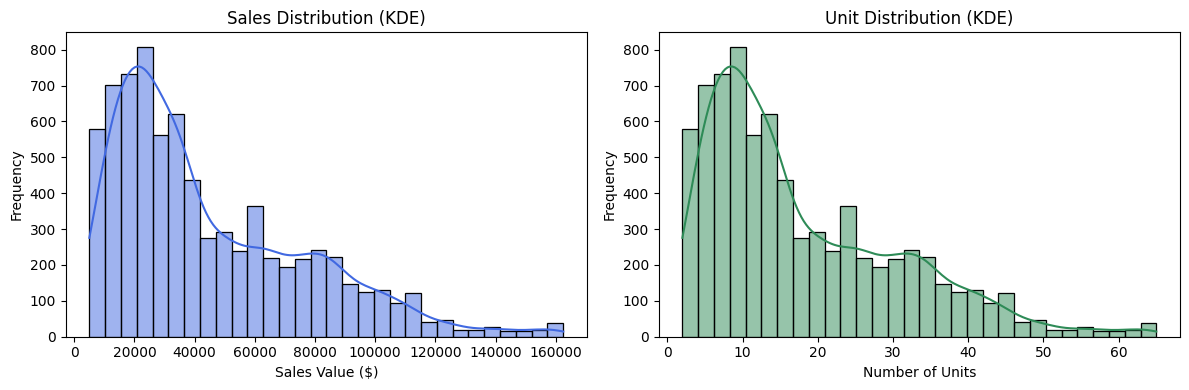

In [65]:
# Distribution plots for Sales and Units
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Sales'], kde=True, color='royalblue', bins=30, ax=axes[0])
axes[0].set_title('Sales Distribution (KDE)')
axes[0].set_xlabel('Sales Value ($)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Unit'],  kde=True, color='seagreen',  bins=30, ax=axes[1])
axes[1].set_title('Unit Distribution (KDE)')
axes[1].set_xlabel('Number of Units')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Note: sns.distplot() is deprecated since Seaborn v0.12.
# The modern equivalent is sns.histplot(kde=True), used above.

In [66]:
# Shapiro-Wilk normality test
# Note: for N > 5000, p-value is approximate — the W statistic remains reliable.
for col in ['Sales', 'Unit']:
    stat, p = shapiro(df[col])
    result  = "Normal" if p > 0.05 else "NOT Normal"
    print(f"{col:6s} — W={stat:.3f}, p={p:.3f} → {result}")

Sales  — W=0.896, p=0.000 → NOT Normal
Unit   — W=0.896, p=0.000 → NOT Normal


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7560.



In [67]:
# Skewness and Kurtosis
for col in ['Sales', 'Unit']:
    print(f"{col:6s} — Skewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurtosis():.2f}")

Sales  — Skewness: 1.09 | Kurtosis: 0.66
Unit   — Skewness: 1.09 | Kurtosis: 0.66


**Statistical Insight:**
- Both `Sales` and `Unit` fail the Shapiro-Wilk test (p < 0.05) — the data is **not normally distributed**.
- **Skewness = 1.09 (right-skewed):** The mean `($45,014)` is pulled upward by high-value transactions. The median `($35,000)` is a more representative central value.
- **Kurtosis = 0.66 (platykurtic):** The distribution is flatter than a normal curve — revenue comes from a broad, diverse set of transaction sizes rather than a narrow cluster.
- **Recommendation:** Use the **median**, not the mean, for target-setting and performance benchmarks.

### f. Normalization

**Approach — Min-Max Normalization (preferred over Standardization here):**
- `Sales` values are in the tens of thousands; `Unit` values are in the double digits.
- Min-Max scaling compresses both to a **[0, 1]** range, enabling fair cross-variable comparison.
- Standardization (z-score) is better suited when data is normally distributed — which this dataset is not.
- Original `Sales` and `Unit` columns are preserved in a separate copy (`df_norm`) for all business reporting.

In [68]:
scaler = MinMaxScaler()

df_norm = df.copy()
df_norm[['Sales_Scaled', 'Unit_Scaled']] = scaler.fit_transform(df[['Sales', 'Unit']])

print("Normalization applied. Sample output:")
df_norm.head()

Normalization applied. Sample output:


,Date,Time,State,Group,Unit,Sales,Sales_Scaled,Unit_Scaled
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873


### g. GroupBy — Data Chunking vs. Merging

**GroupBy is used throughout this analysis for data chunking** — splitting the dataset into meaningful segments (by State, Group, and Time) to compute aggregated metrics per segment.

- **Data chunking** (used here): `groupby('State')` splits rows into 7 state buckets and computes sum/mean/count independently per bucket. Ideal when the goal is segment-level comparison.
- **Data merging** (not used here): `groupby` followed by a join/merge combines aggregated results back into a broader dataset. Useful when enriching a transactional table with group-level statistics.

**Recommendation for this dataset:** Chunking is the correct approach. We want to compare performance *between* segments (state vs. state, group vs. group), not enrich individual rows with aggregate values.

---
## **2. Data Analysis**

### a. Descriptive Statistics

In [69]:
# Descriptive stats for Sales and Unit
desc_stats = df[['Sales', 'Unit']].describe().T

# Add Mode (not included in .describe())
desc_stats['mode'] = [df['Sales'].mode()[0], df['Unit'].mode()[0]]

print("Descriptive Statistics:")
desc_stats

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,mode
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0,22500
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0,9


**Descriptive Statistics Insights:**
- The dataset has 7,560 transactions with high average transaction value `($45,014)` and significant variance `(std = $32,253)`.
- Since the distribution is **right-skewed**, the mean `($45,014)` exceeds the median `($35,000)` — high-value deals pull the average upward.
- Bottom 25% of transactions are at `$20,000`; top performers reach `$162,500`.
- Units sold are comparatively stable (median = 14, max = 65), suggesting high revenue is driven more by price point than pure volume.

### b & c. Highest and Lowest Sales Groups

In [70]:
# Group-level aggregation
group_sales      = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales_unit = df.groupby('Group')['Unit'].sum().sort_values(ascending=False)

print(f"Highest Sales Group : {group_sales.idxmax()} (${group_sales.max():,.0f})")
print(f"Lowest  Sales Group : {group_sales.idxmin()} (${group_sales.min():,.0f})")
print(f"Highest Units Group : {group_sales_unit.idxmax()} ({group_sales_unit.max():,.0f} units)")
print(f"Lowest  Units Group : {group_sales_unit.idxmin()} ({group_sales_unit.min():,.0f} units)")

Highest Sales Group : Men ($85,750,000)
Lowest  Sales Group : Seniors ($84,037,500)
Highest Units Group : Men (34,300 units)
Lowest  Units Group : Seniors (33,615 units)


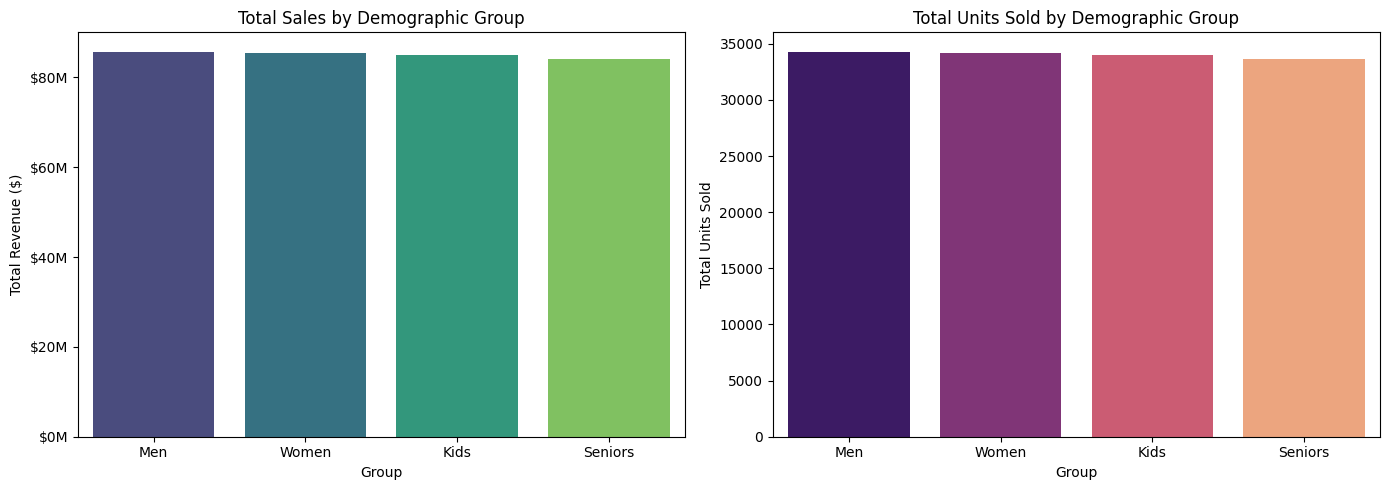

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=group_sales.index,      y=group_sales.values,      ax=ax[0],
            hue=group_sales.index,      palette='viridis', legend=False)
ax[0].set_title('Total Sales by Demographic Group')
ax[0].set_ylabel('Total Revenue ($)')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.barplot(x=group_sales_unit.index, y=group_sales_unit.values, ax=ax[1],
            hue=group_sales_unit.index, palette='magma',   legend=False)
ax[1].set_title('Total Units Sold by Demographic Group')
ax[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

**Insight:**
Surprisingly, all four demographic groups contribute almost equally (~25% each):
- **Highest Sales:** Men — `$85,750,000 (34,300 units)`
- **Lowest Sales:** Seniors — `$84,037,500 (33,615 units)`
- The gap between highest and lowest is only `~$1.7M (< 2%)` — confirming AAL's **universal brand appeal** across all age and gender segments.

### State-Level Sales Analysis

In [72]:
state_sales = df.groupby('State')[['Sales', 'Unit']].sum().sort_values(by='Sales', ascending=False)
print("State-wise Sales & Units:")
print(state_sales)

State-wise Sales & Units:
           Sales   Unit
State                  
VIC    105565000  42226
NSW     74970000  29988
SA      58857500  23543
QLD     33417500  13367
TAS     22760000   9104
NT      22580000   9032
WA      22152500   8861


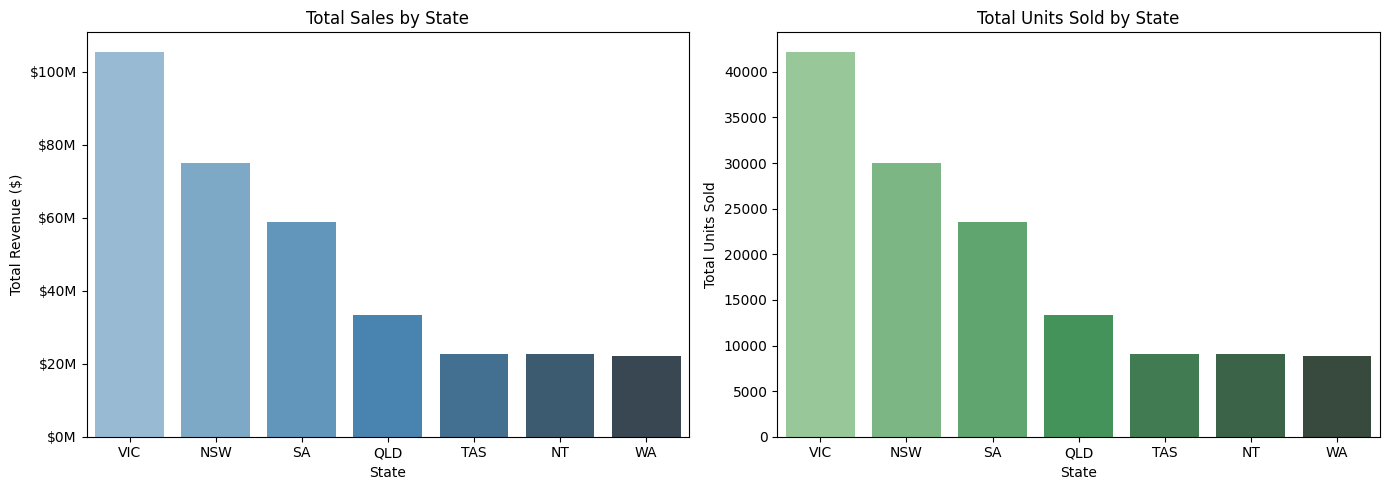

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=state_sales.index, y=state_sales['Sales'], ax=ax[0],
            hue=state_sales.index, palette='Blues_d', legend=False)
ax[0].set_title('Total Sales by State')
ax[0].set_ylabel('Total Revenue ($)')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.barplot(x=state_sales.index, y=state_sales['Unit'], ax=ax[1],
            hue=state_sales.index, palette='Greens_d', legend=False)
ax[1].set_title('Total Units Sold by State')
ax[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

**Insight:**
- **VIC (Victoria)** dominates with `$105,565,000` — nearly **4.8x the revenue of WA** `($22,152,500)`, the lowest-performing state.
- Top 3 states (VIC, NSW, SA) generate 70.3% of all Q4 revenue.
- Bottom 4 states (QLD, TAS, NT, WA) generate only 29.7% combined — clear targets for AAL's sales development investment.

### Time-of-Day Analysis

In [74]:
time_sales = df.groupby('Time')[['Sales', 'Unit']].sum().sort_values(by='Sales', ascending=False)
print("Sales & Units by Time of Day:")
print(time_sales)

Sales & Units by Time of Day:
               Sales   Unit
Time                       
Morning    114207500  45683
Afternoon  114007500  45603
Evening    112087500  44835


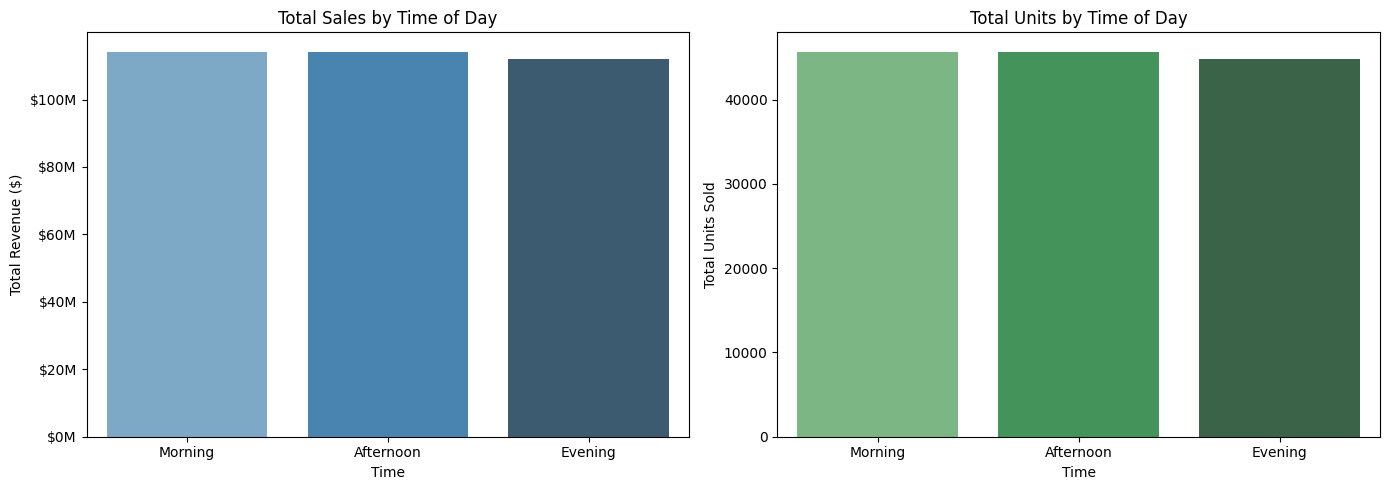

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=time_sales.index, y=time_sales['Sales'], ax=ax[0],
            hue=time_sales.index, palette='Blues_d', legend=False)
ax[0].set_title('Total Sales by Time of Day')
ax[0].set_ylabel('Total Revenue ($)')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.barplot(x=time_sales.index, y=time_sales['Unit'], ax=ax[1],
            hue=time_sales.index, palette='Greens_d', legend=False)
ax[1].set_title('Total Units by Time of Day')
ax[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

**Insight:**
- **Morning** is the peak time slot `($114.2M)`, but the margin over Afternoon `($114.0M)` is only `$200K — less than 0.2%`.
- **Evening** is the only slot below the daily average `($112.1M)`, representing `~$2M` in untapped potential.
- The near-uniform spread across time windows is unusual for retail and signals an opportunity to create deliberate peaks through targeted promotions (e.g., evening flash sales, hyper-personalisation, Next Best Offer programs).

### Group × State Heatmap

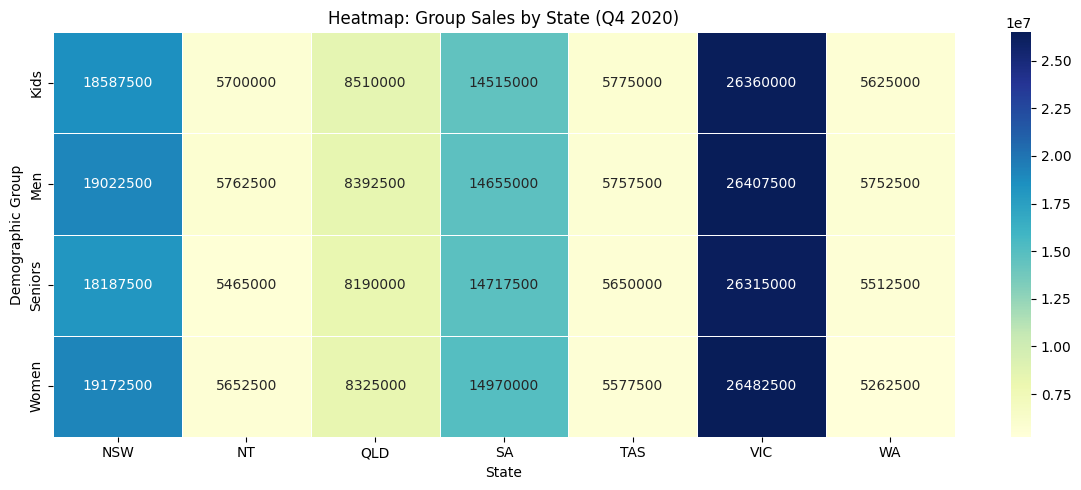

In [76]:
state_group_pivot = df.pivot_table(index='Group', columns='State', values='Sales', aggfunc='sum')

plt.figure(figsize=(12, 5))
sns.heatmap(state_group_pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white')
plt.title('Heatmap: Group Sales by State (Q4 2020)')
plt.ylabel('Demographic Group')
plt.xlabel('State')
plt.tight_layout()
plt.show()

**Insight:**
VIC leads in every single demographic group, and WA trails in all. The geographic gap is **systemic** — not driven by any single product category. Sales development programs for lower-revenue states should target all demographic segments, not just one.

### Units–Sales Correlation

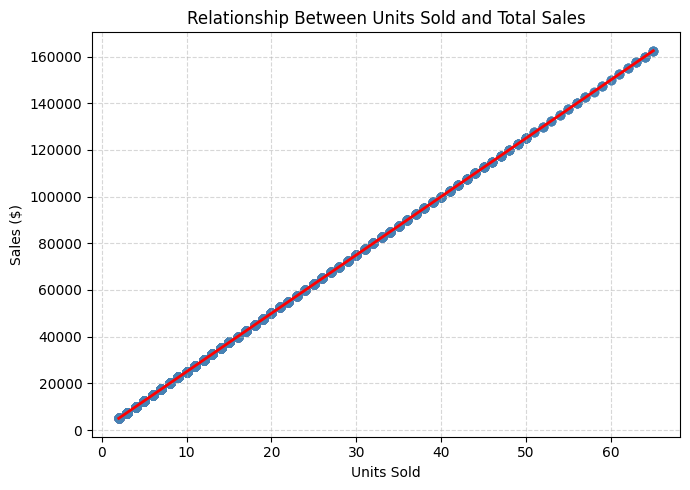

In [77]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Unit', y='Sales',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Relationship Between Units Sold and Total Sales')
plt.xlabel('Units Sold')
plt.ylabel('Sales ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observations:**
- **Near-perfect positive correlation** — data points cluster almost exactly on the regression line (R² ≈ 1.0).
- **Constant price per unit** — the near-zero scatter indicates price per unit is consistent across virtually all transactions.
- **Implication:** Revenue growth is entirely volume-driven at current pricing. NBO and cross-sell programs should focus on increasing units per basket rather than offering price discounts.

### d. Weekly, Monthly & Quarterly Reports

In [78]:
# Quarterly report
quarterly_report = df_indexed.resample('QE')[['Sales', 'Unit']].sum()
print("--- Quarterly Sales Report ---")
print(quarterly_report)

# Monthly report
monthly_report = df_indexed.resample('ME')[['Sales', 'Unit']].sum()
print("\n--- Monthly Sales Report ---")
print(monthly_report)

# Weekly report
weekly_report = df_indexed.resample('W')[['Sales', 'Unit']].sum()
print("\n--- Weekly Sales Report ---")
print(weekly_report)

# Daily report
daily_report = df_indexed.resample('D')[['Sales', 'Unit']].sum()
print("\n--- Daily Sales Report ---")
print(daily_report)

--- Quarterly Sales Report ---
                Sales    Unit
Date                         
2020-12-31  340302500  136121

--- Monthly Sales Report ---
                Sales   Unit
Date                        
2020-10-31  114290000  45716
2020-11-30   90682500  36273
2020-12-31  135330000  54132

--- Weekly Sales Report ---
               Sales   Unit
Date                       
2020-10-04  15045000   6018
2020-10-11  27002500  10801
2020-10-18  26640000  10656
2020-10-25  26815000  10726
2020-11-01  21807500   8723
2020-11-08  20865000   8346
2020-11-15  21172500   8469
2020-11-22  21112500   8445
2020-11-29  21477500   8591
2020-12-06  29622500  11849
2020-12-13  31525000  12610
2020-12-20  31655000  12662
2020-12-27  31770000  12708
2021-01-03  13792500   5517

--- Daily Sales Report ---
              Sales  Unit
Date                     
2020-10-01  3720000  1488
2020-10-02  3715000  1486
2020-10-03  3890000  1556
2020-10-04  3720000  1488
2020-10-05  3862500  1545
...             .

**Note:** Pandas frequency aliases used — `'QE'` (Quarter End), `'ME'` (Month End), `'W'` (Week End Sunday). The legacy `'Q'` and `'M'` aliases are deprecated in Pandas ≥ 2.2.

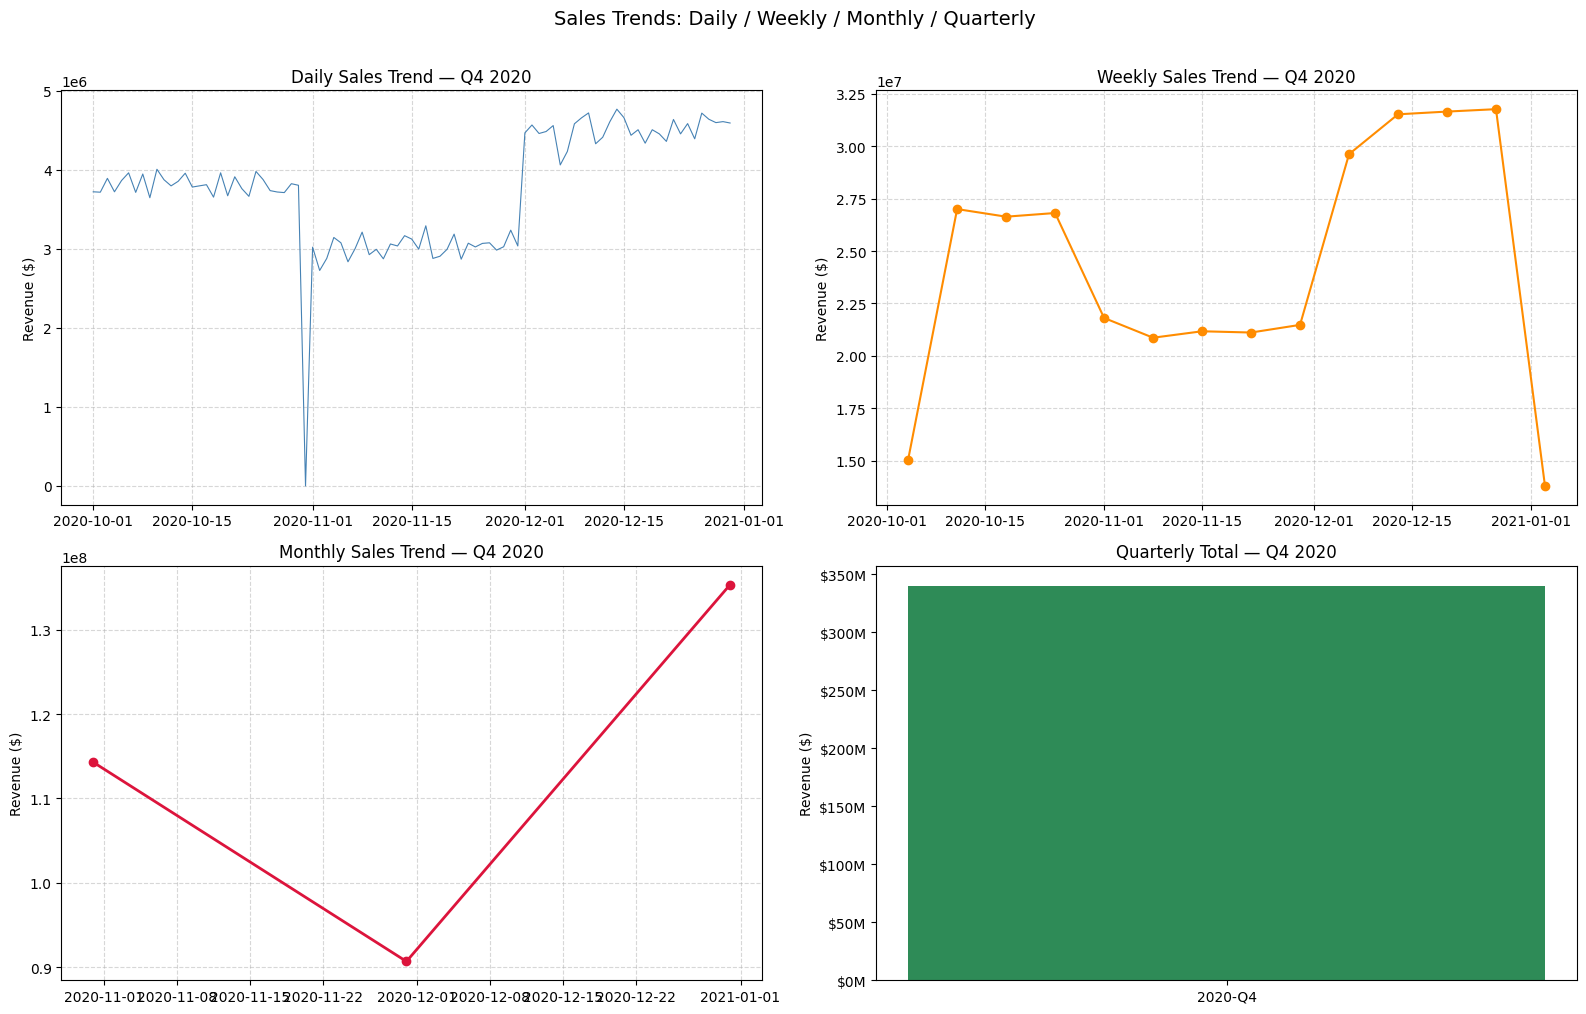

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily
axes[0, 0].plot(daily_report.index, daily_report['Sales'], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Daily Sales Trend — Q4 2020')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Weekly
axes[0, 1].plot(weekly_report.index, weekly_report['Sales'], marker='o', color='darkorange', linewidth=1.5)
axes[0, 1].set_title('Weekly Sales Trend — Q4 2020')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Monthly
axes[1, 0].plot(monthly_report.index, monthly_report['Sales'], marker='o', color='crimson', linewidth=2)
axes[1, 0].set_title('Monthly Sales Trend — Q4 2020')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Quarterly (bar — only 1 data point)
axes[1, 1].bar(quarterly_report.index.strftime('%Y-Q4'), quarterly_report['Sales'], color='seagreen', width=0.4)
axes[1, 1].set_title('Quarterly Total — Q4 2020')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

plt.suptitle('Sales Trends: Daily / Weekly / Monthly / Quarterly', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Time-Series Insights:**
- **October** opened strong at `$114.3M` — end-of-season and early summer demand.
- **November** dipped sharply to `$90.7M (−20.7%)` — the post-October lull before festive season.
- **December** surged to `$135.3M (+49.2%)` — the highest month, driven by Christmas gifting.
- The five-week November trough `(avg ~$21M/week)` is the clearest recoverable gap — a targeted Black Friday / Cyber Week campaign could close a meaningful portion of this.

---
## 3. Interactive Dashboard

**Visualisation library recommendation:**
- **Seaborn** — preferred for statistical analysis (distributions, box plots, heatmaps) due to its tight Pandas integration and clean defaults. Used throughout Sections 1 & 2.
- **Matplotlib** — base rendering engine; used for trend lines and multi-panel layouts.
- **Plotly** — used for the interactive dashboard below. Allows the S&M head to hover, zoom, and filter — making it the best choice for an executive-facing deliverable.

The dashboard below consolidates all key metrics into a single interactive view.

In [80]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Weekly Sales Trend", "Monthly Revenue Split", "Sales by Demographic Group",
        "Sales by State",     "Units by State",        "Sales by Time of Day"
    ),
    specs=[
        [{"type": "xy"},     {"type": "domain"}, {"type": "xy"}],
        [{"type": "xy"},     {"type": "xy"},     {"type": "xy"}]
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.08
)

# Row 1 — Time & Demographics
fig.add_trace(go.Bar(
    x=weekly_report.index, y=weekly_report['Sales'],
    marker_color='#636EFA', name='Weekly Sales'
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=monthly_report.index.strftime('%B'),
    values=monthly_report['Sales'],
    hole=0.4, name='Monthly Split'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=group_sales.index, y=group_sales.values,
    marker_color='#00CC96', name='Group Sales'
), row=1, col=3)

# Row 2 — Geography & Time of Day
fig.add_trace(go.Bar(
    x=state_sales.index, y=state_sales['Sales'],
    marker_color='#EF553B', name='State Sales'
), row=2, col=1)

fig.add_trace(go.Bar(
    x=state_sales.index, y=state_sales['Unit'],
    marker_color='#AB63FA', name='State Units'
), row=2, col=2)

time_analysis = df.groupby('Time')[['Sales', 'Unit']].sum()
fig.add_trace(go.Bar(
    x=time_analysis.index, y=time_analysis['Sales'],
    marker_color='#FFA15A', name='Time Sales'
), row=2, col=3)

fig.update_layout(
    template='plotly_dark',
    title_text='AAL Strategic Summary Dashboard — Q4 2020',
    title_font_size=18,
    height=850,
    showlegend=False
)

# Currency formatting on revenue axes
for r, c in [(1,1),(1,3),(2,1),(2,3)]:
    fig.update_yaxes(tickprefix='$', row=r, col=c)

fig.show()

---
## 4. Report Summary & Recommendations

### Executive Summary

AAL Apparel generated **`$340.3 million`** in total revenue across Australia during Q4 2020 (October–December), spanning **7,560 transactions** across seven states and four demographic groups.

---

### Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Geographic concentration** | VIC leads at `$105.6M` — 4.8× the lowest state `(WA, $22.2M)`. Top 3 states (VIC, NSW, SA) account for 70% of all revenue. |
| 2 | **Balanced demographics** | All four groups contribute ~25% each `(Men $85.75M → Seniors $84.04M)`. Universal brand appeal confirmed. |
| 3 | **November trough** | Revenue dipped 20.7% in November `($90.7M)` before surging 49.2% in December `($135.3M)`. The Nov gap is the biggest recoverable opportunity. |
| 4 | **Flat time-of-day distribution** | Morning, Afternoon, and Evening are within 2% of each other — unusual for retail, and a signal that deliberate peak creation via promotions is viable. |
| 5 | **Constant price per unit** | Near-perfect linear correlation between units and sales (R² ≈ 1.0) confirms a fixed price point. Revenue growth = volume growth. |
| 6 | **Right-skewed distribution** | Mean `($45,014)` overstates a typical transaction by ~$10K vs. median `($35,000)`. Use the median for target-setting. |

---

### Strategic Recommendations

1. **November Activation Campaign** — Build a Black Friday / Cyber Week / pre-Christmas campaign to recover the November trough. Target: `+$7–12M` vs. prior year.

2. **State Expansion: QLD & SA** — QLD `($33.4M)` underperforms relative to its population. SA `($58.9M)` has traction. Both are lower-risk expansion targets before investing in NT/WA.

3. **Evening 'After Hours' Push** — Deploy time-limited evening promotions (5–7 pm) targeting Women and Seniors. A 3% Evening lift = `~$3.4M` additional Q4 revenue.

4. **Seniors Initiative** — The only segment trailing all others. Review product range adequacy for 65+ and pilot a Seniors Loyalty Programme in WA and NT as a market-entry wedge.

5. **Reset targets to Median** — All internal performance benchmarks must use `$35,000` (median), not `$45,014` (mean). Using the mean creates systematically unrealistic targets for the majority of stores.

---


_This analysis was conducted in Python (Pandas, NumPy, SciPy, Seaborn, Matplotlib, Plotly) within a Google Collab Notebook environment, consistent with the Applied Data Science with Python project requirements._
